# 실습 내용

- K-Fold Cross Validation을 사용해 모델의 성능을 예측한다.

# 1.환경 준비

In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

In [2]:
# 데이터 읽어오기
path = './../00_data/boston.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [3]:
# 데이터 살펴보기
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [4]:
# 기술통계 확인
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


# 3.데이터 전처리

**1) x, y 분리**

In [5]:
# Target 확인
target = 'medv'


# x, y 분리
X = df.drop(target, axis=1)
y = df[target]


**2) 학습용, 평가용 데이터 분리**

In [6]:
# 라이브러리 불러오기
from sklearn.model_selection import train_test_split

# 학습용, 평가용 데이터 7:3으로 분리

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1)


**3) 정규화**

In [7]:
# 모듈 불러오기
from sklearn.preprocessing import MinMaxScaler

# 정규화
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)


# 4.성능 예측

- K분할 교차 검증 방법으로 모델 성능을 예측
- `cross_val_score(model, x_train, y_train, cv=n)` 형태로 사용
- cv 옵션에 k값(분할 개수, 기본값=5)을 지정
- cross_val_score 함수는 넘파이 배열 형태의 값을 반환
- cross_val_score 함수 반환 값의 평균을 해당 모델의 예측 성능으로 볼 수 있다.


**1) Linear Regression**

In [8]:
# 불러오기
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


# 선언하기
model_lr = LinearRegression()


# 검증하기
cv_score = cross_val_score(model_lr, X_train, y_train, cv=10, scoring='neg_mean_absolute_error')

# 확인
print(cv_score)
print('평균 : ', cv_score.mean()) # 모델의 평균 성능 평가 (일반적인 성능을 대표하는 값)
print('표준편차 : ', cv_score.std()) # 모델 성능의 일관성 평가 (표준편차가 작다면 -> 모델이 안정적)

# 성능 정보 수집
result = {}
result['Linear Regression'] = abs(cv_score.mean())


[-3.36542495 -3.74183784 -3.64295403 -3.5746592  -2.85180744 -3.94321406
 -4.07635369 -3.87615772 -3.83998783 -2.52647884]
평균 :  -3.54388755952415
표준편차 :  0.4729640935387566


**2) KNN**

In [9]:
# 불러오기
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score


# 선언하기
model_knn = KNeighborsRegressor()


# 검증하기
cv_score = cross_val_score(model_knn, X_train_s, y_train, cv=10, scoring='r2')

# 확인
print(cv_score)
# 확인
print(cv_score)
print('평균 :', cv_score.mean())           # 모델의 평균 성능 평가(일반적인 성능을 대표하는 값)
print('표준편차 :', cv_score.std())         # 모델 성능의 일관성 평가(표준편차가 작다면 -> 모델이 안정적)

# 성능 정보 수집
result['KNN'] = cv_score.mean()


[0.66016713 0.5374565  0.7131859  0.50375049 0.75186209 0.6626164
 0.56052422 0.63689217 0.44663026 0.83130085]
[0.66016713 0.5374565  0.7131859  0.50375049 0.75186209 0.6626164
 0.56052422 0.63689217 0.44663026 0.83130085]
평균 : 0.6304385997339291
표준편차 : 0.11281238435977889


**3) Decision Tree**

In [10]:
# 불러오기
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score


# 선언하기
model_dt = DecisionTreeRegressor(max_depth=5, random_state=1)

# 검증하기
cv_score = cross_val_score(model_dt, X_train, y_train, cv=10, scoring='neg_mean_absolute_error')

# 확인

print(cv_score)
print('평균 : ', cv_score.mean()) # 모델의 평균 성능 평가 (일반적인 성능을 대표하는 값)
print('표준편차 : ', cv_score.std()) # 모델 성능의 일관성 평가 (표준편차가 작다면 -> 모델이 안정적)

# 성능 정보 수집
result['Decision Tree'] = abs(cv_score.mean())


[-2.71303764 -2.70180064 -2.34809543 -2.79874048 -3.07000563 -2.76426361
 -3.37935438 -3.25560384 -2.74484554 -2.03923566]
평균 :  -2.781498284051005
표준편차 :  0.37645884695079734


**4) SVM**

In [11]:
# 불러오기
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score


# 선언하기
model = SVR()

# 검증하기
cv_score = cross_val_score(model, X_train_s, y_train, cv=10, scoring='neg_mean_absolute_error')

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())


#정보 수집
result['SVM'] = abs(cv_score.mean())



[-2.96672881 -3.57889543 -4.26690765 -3.05299803 -2.6412347  -4.17435889
 -4.59857241 -4.64749451 -3.50335855 -3.03671193]
평균: -3.646726091633257
표준편차: 0.6923702164226938


# 5. 성능 비교

In [12]:
result

{'Linear Regression': np.float64(3.54388755952415),
 'KNN': np.float64(0.6304385997339291),
 'Decision Tree': np.float64(2.781498284051005),
 'SVM': np.float64(3.646726091633257)}

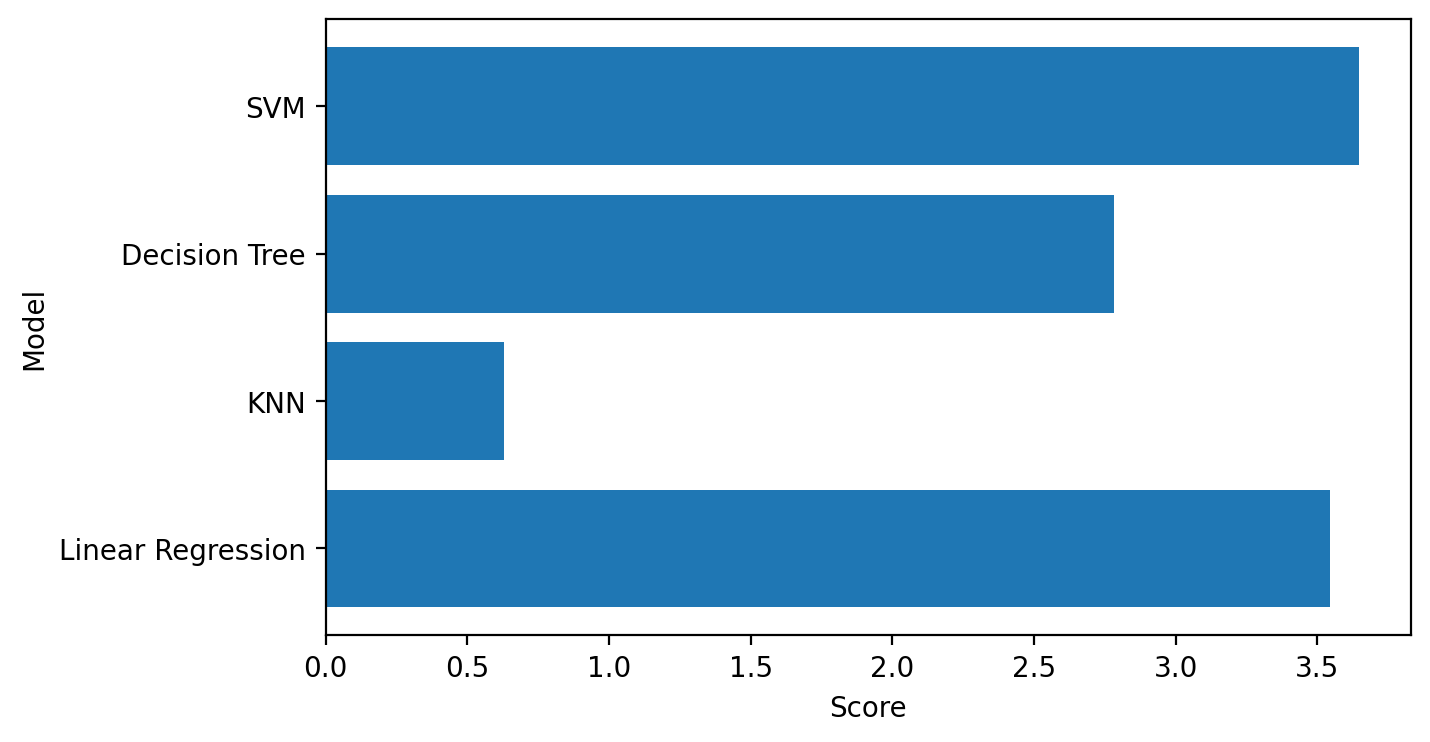

In [13]:
# 시각화
plt.figure(figsize=(7,4))
plt.barh(y=list(result), width=result.values(), data=result)
plt.ylabel('Model')
plt.xlabel('Score')
plt.show()

# 6. 실제 성능 비교

In [14]:
from sklearn.metrics import r2_score

# 선언하기
model = SVR(kernel='linear', C=1, gamma=1)

model.fit(X, y)

y_pred = model.predict(X_test)


print(r2_score(y_test, y_pred))


0.7872537466742207
